Atividade 4

André Luiz Queiroz Valpassos

Luis Ernani Viniski

Leonardo Barbosa dos Santos

Gabriel Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as sts
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, single, average, fcluster
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
#Importando os dados
url = "https://raw.githubusercontent.com/devjaynemorais/modelos_descritivos_curso/main/Aula%2002/dados/country_data.csv"
df = pd.read_csv(url)

In [ ]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [ ]:
#Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
#Estatísticas do Dataset
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
#Verificando se existem linhas duplicadas
df.duplicated().sum()

0

In [ ]:
# Selecionar apenas as colunas mais importantes para a clusterização
df_filtered = df.drop(columns=['country', 'exports', 'imports'])
X = df_filtered

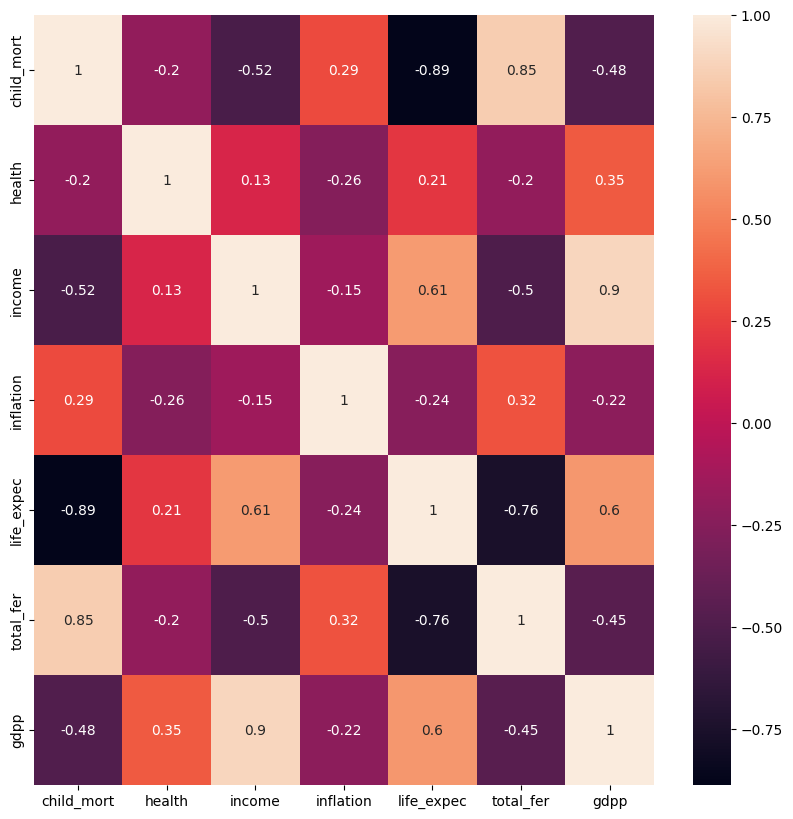

In [ ]:
plt.figure(figsize = (10, 10))
sns.heatmap(X.corr(), annot = True)
plt.savefig('Correlation')
plt.show()

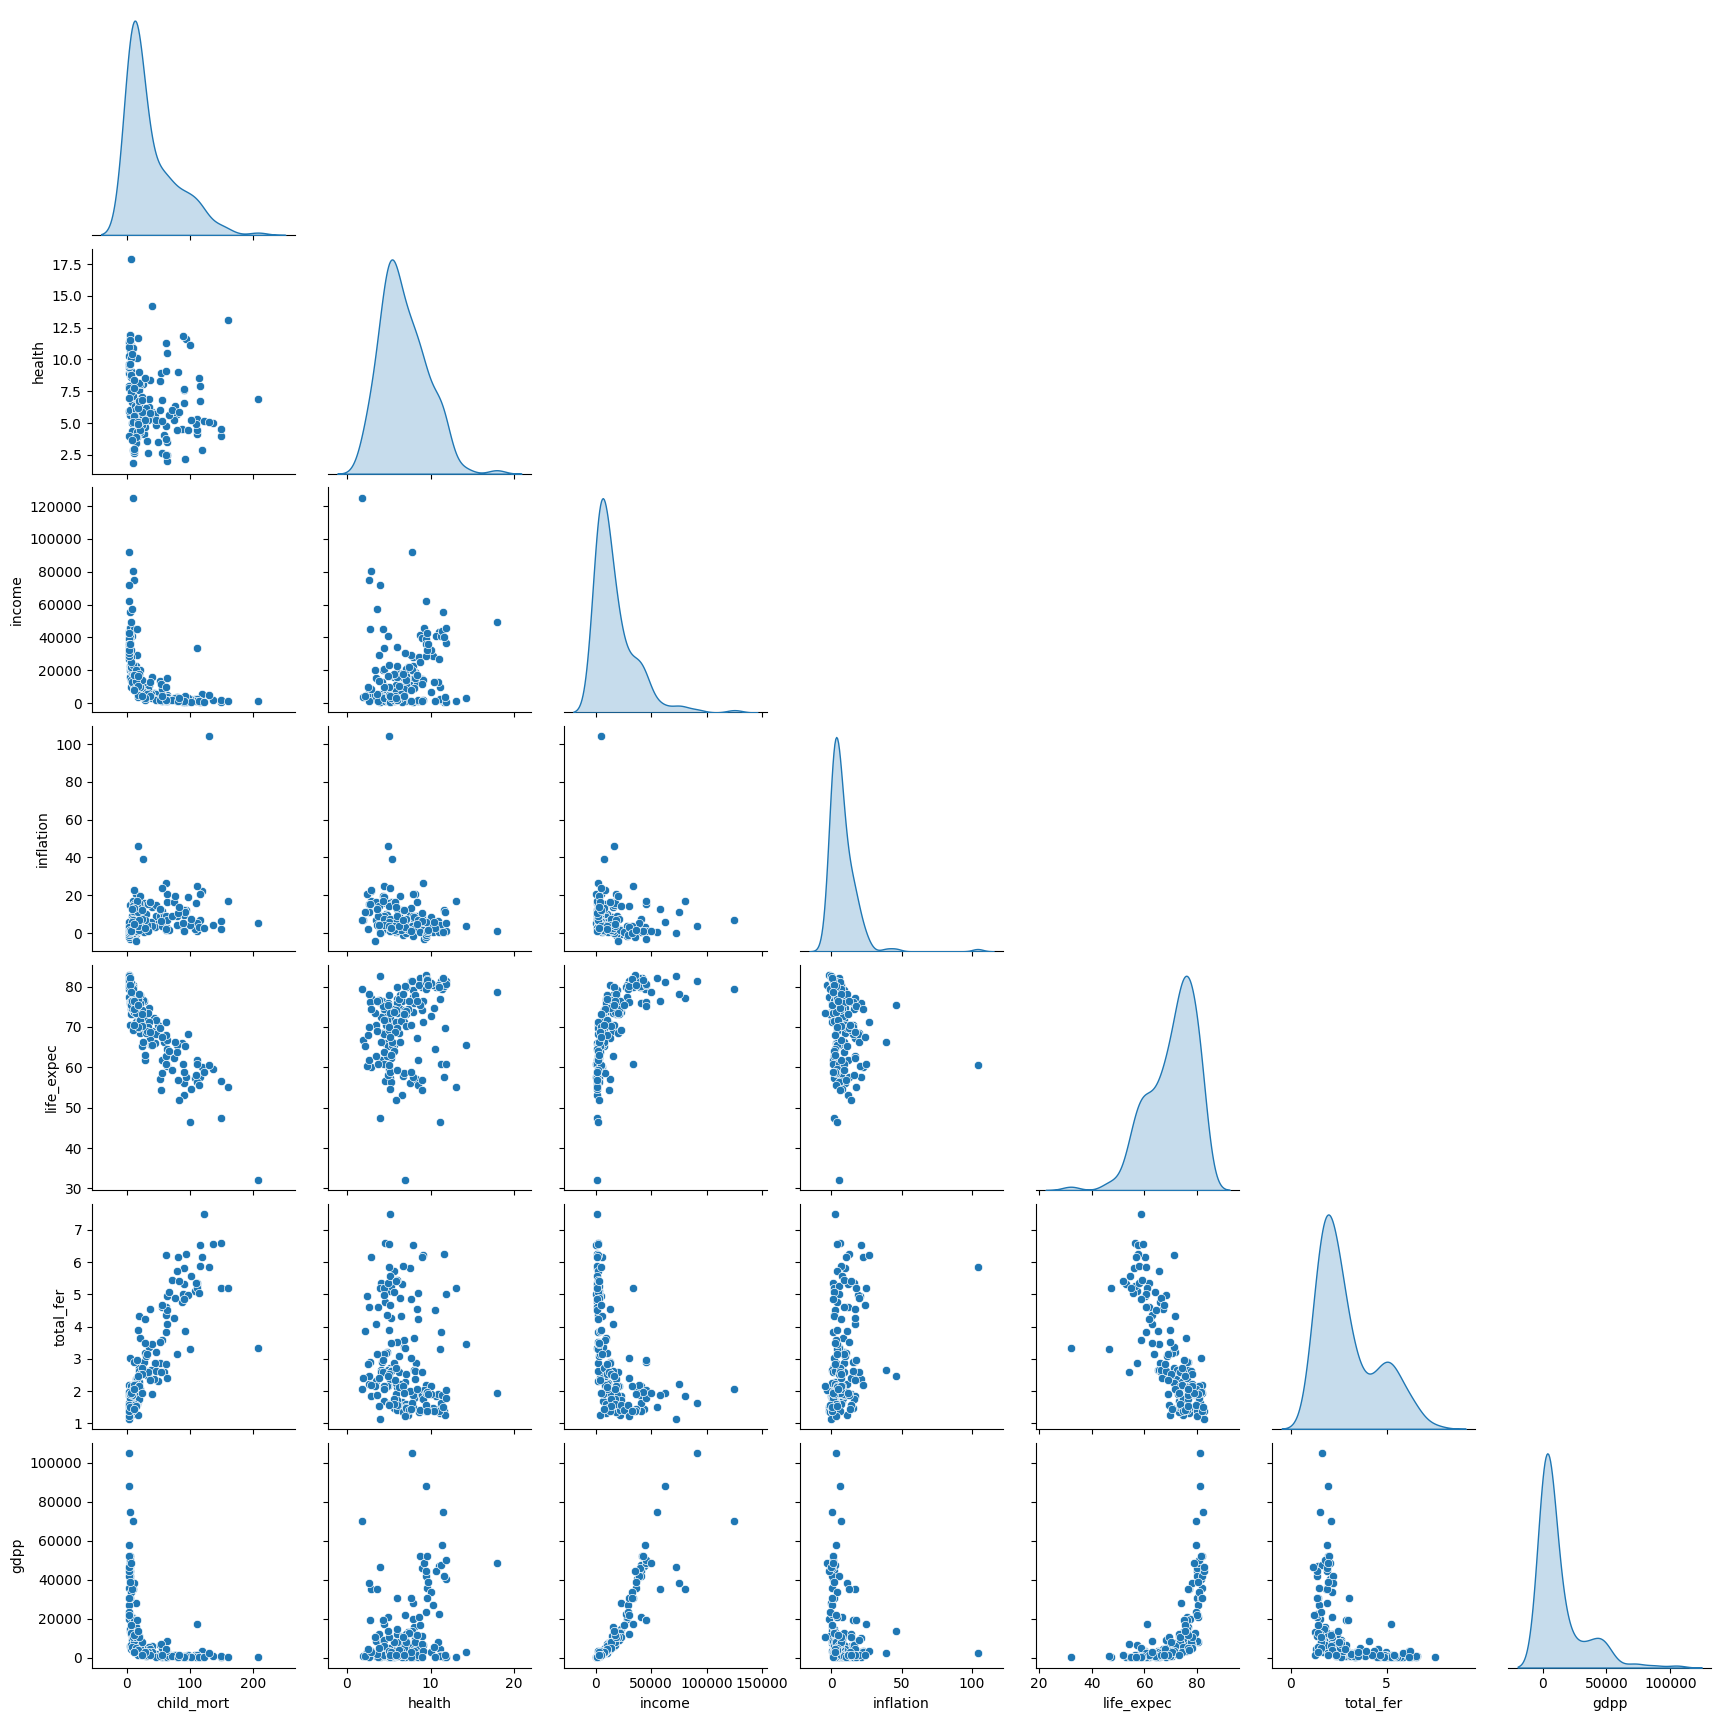

In [ ]:
sns.pairplot(X,corner=True,diag_kind="kde")
plt.show()

In [ ]:
# Selecionar colunas numéricas para normalização
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Inicializar o scaler
scaler = StandardScaler()

# Aplicar a normalização
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

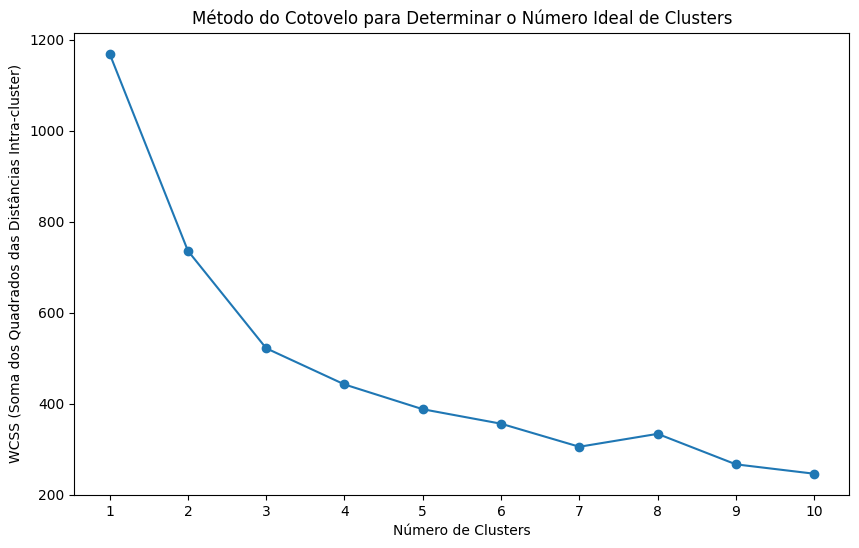

In [ ]:
# Determinar o número ideal de clusters usando o método do cotovelo
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-')
plt.title('Método do Cotovelo para Determinar o Número Ideal de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS (Soma dos Quadrados das Distâncias Intra-cluster)')
plt.xticks(range(1, 11))
plt.show()

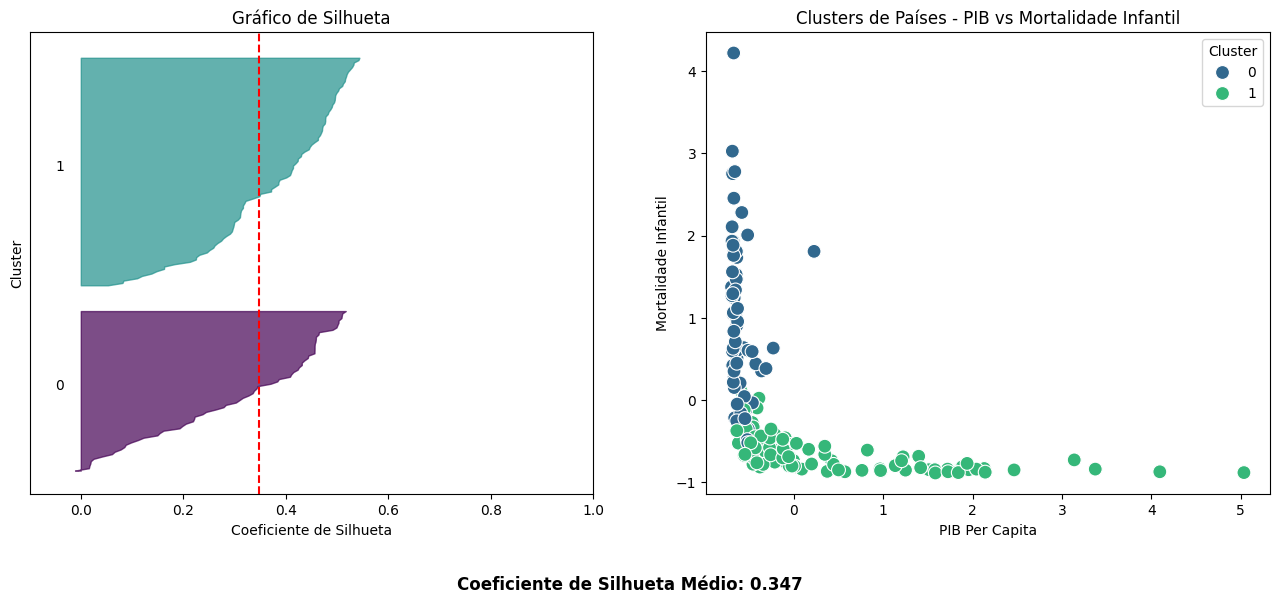

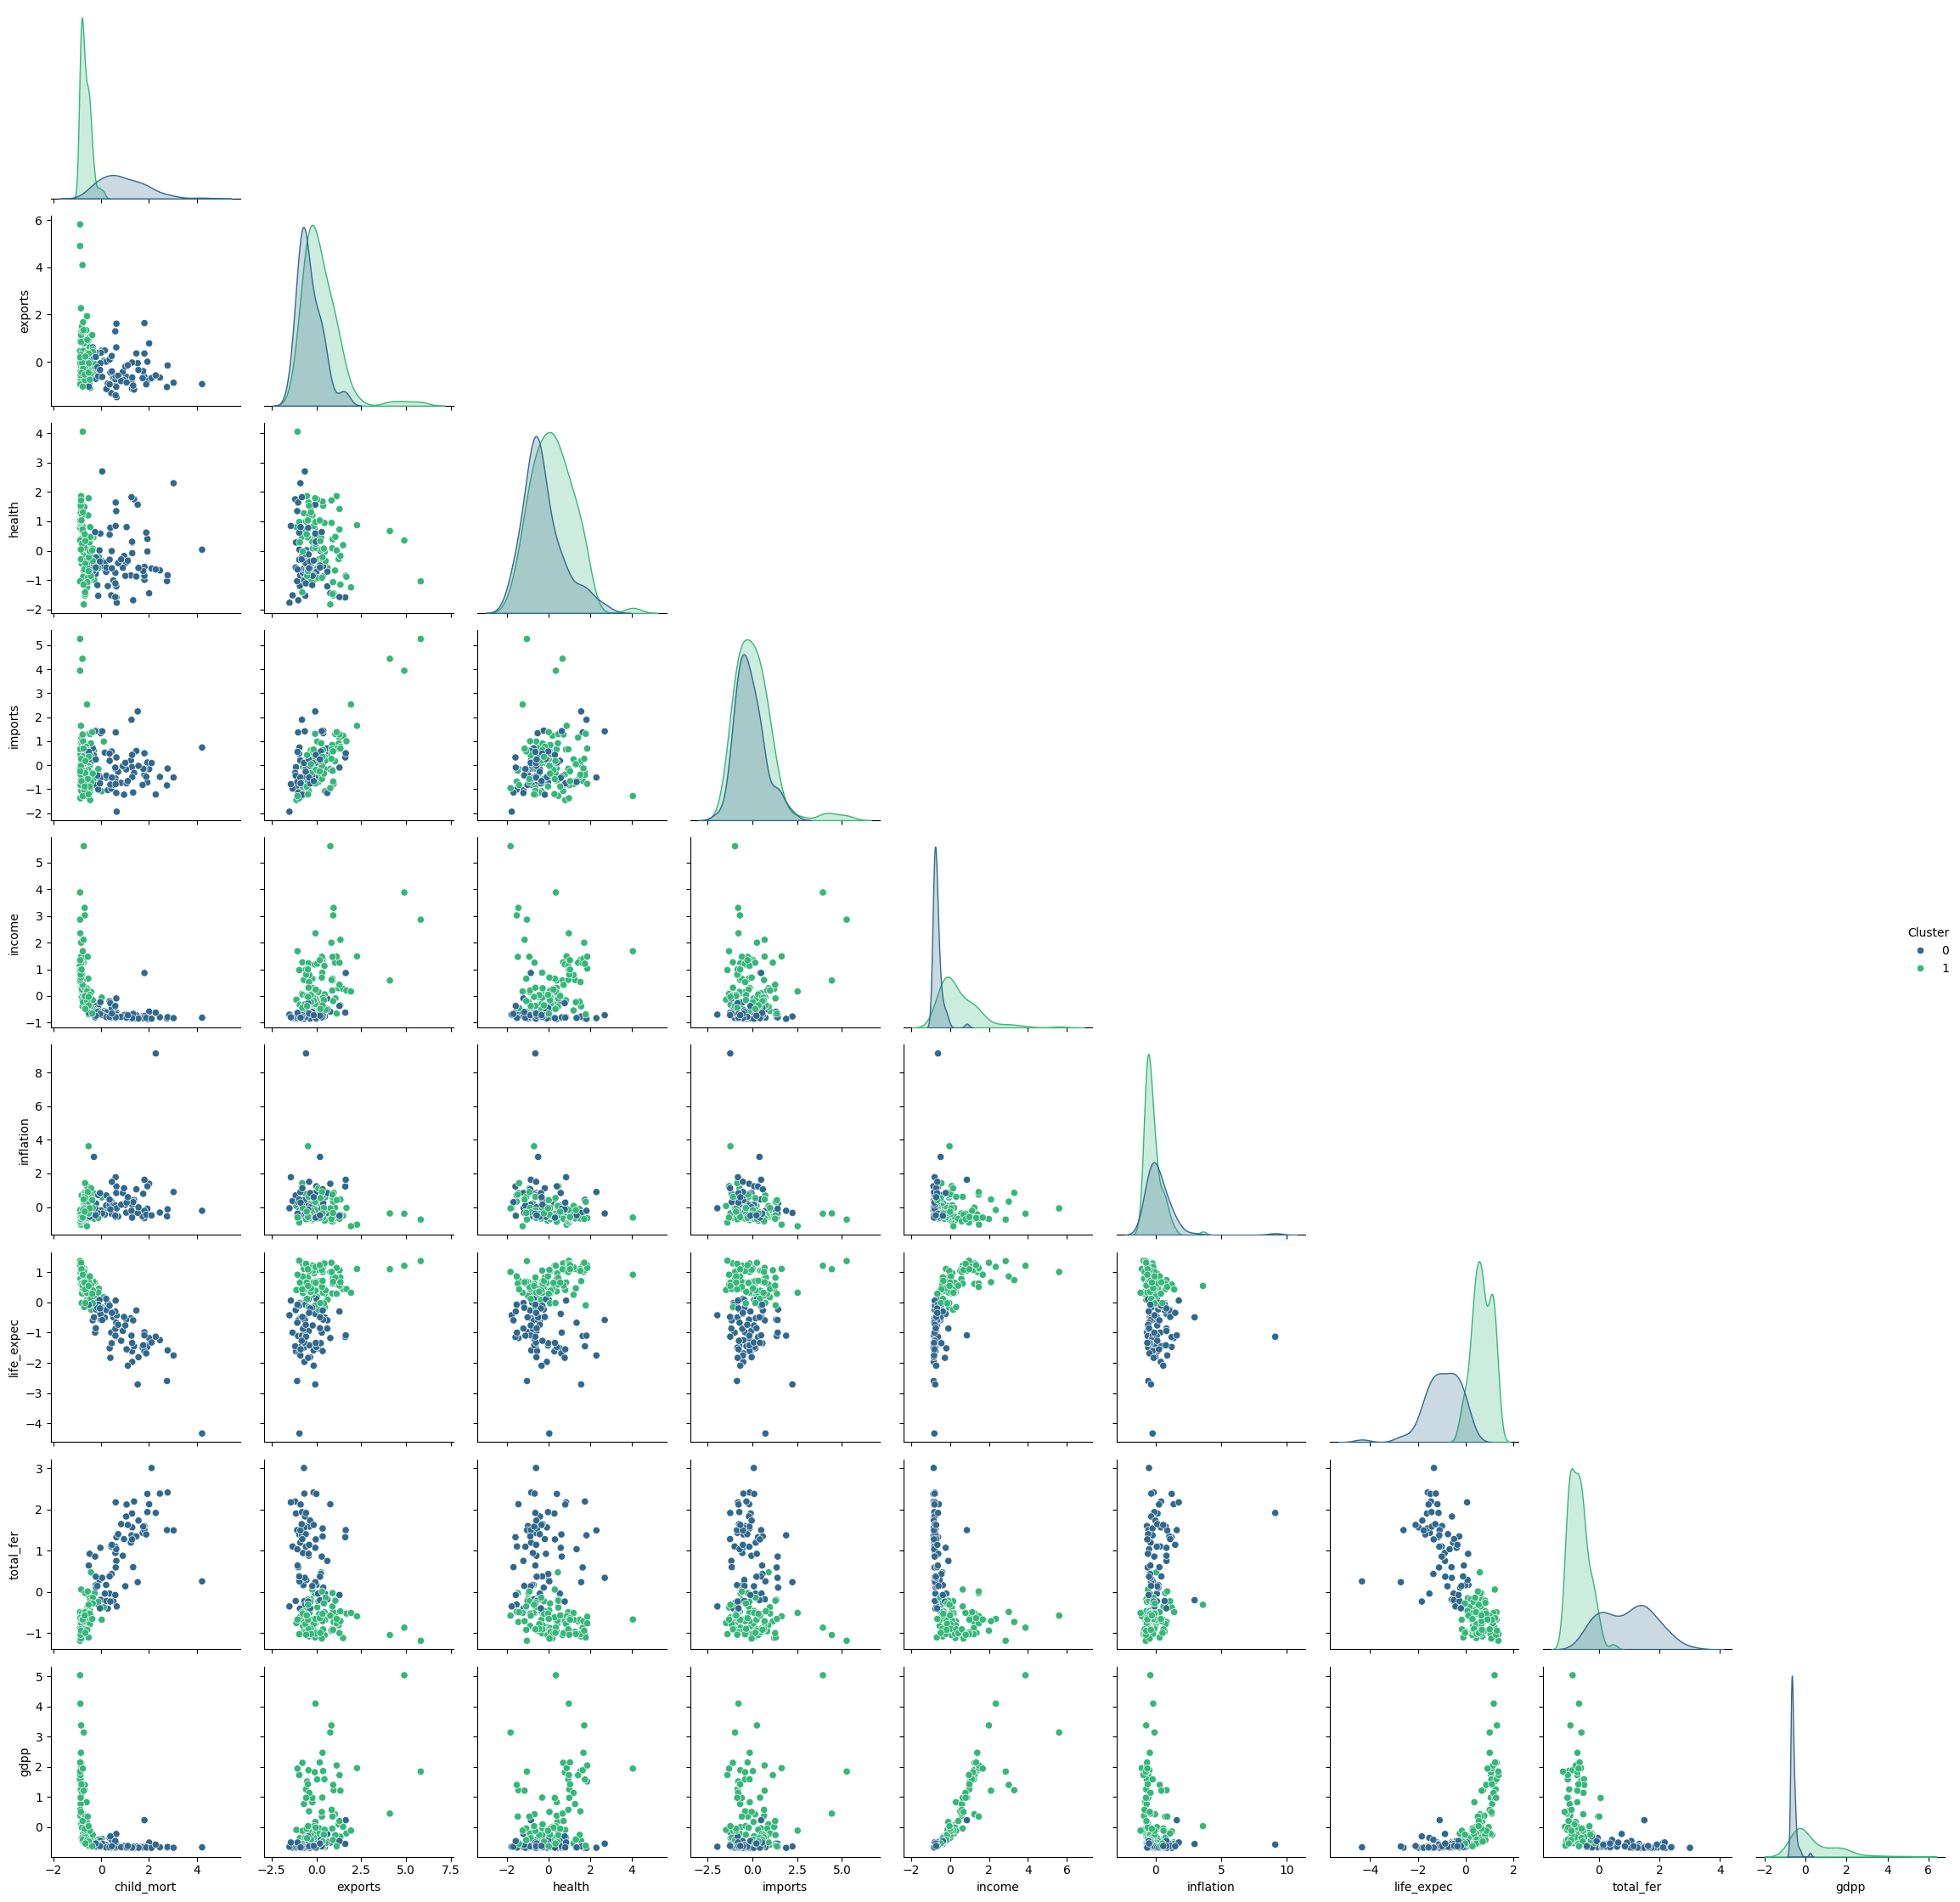

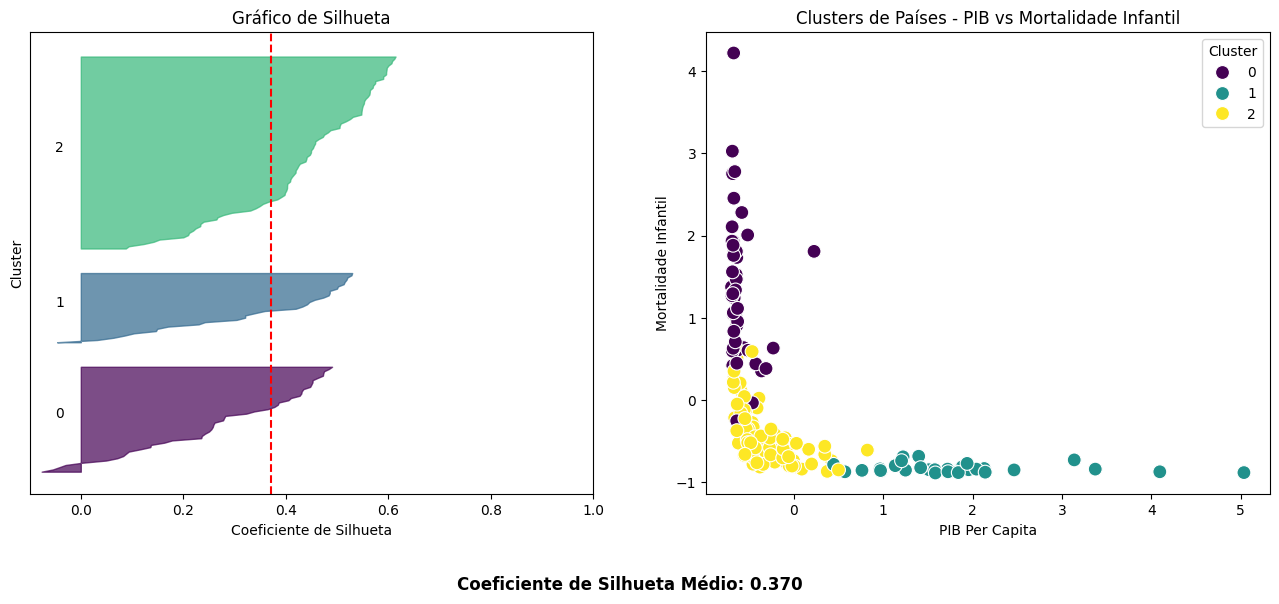

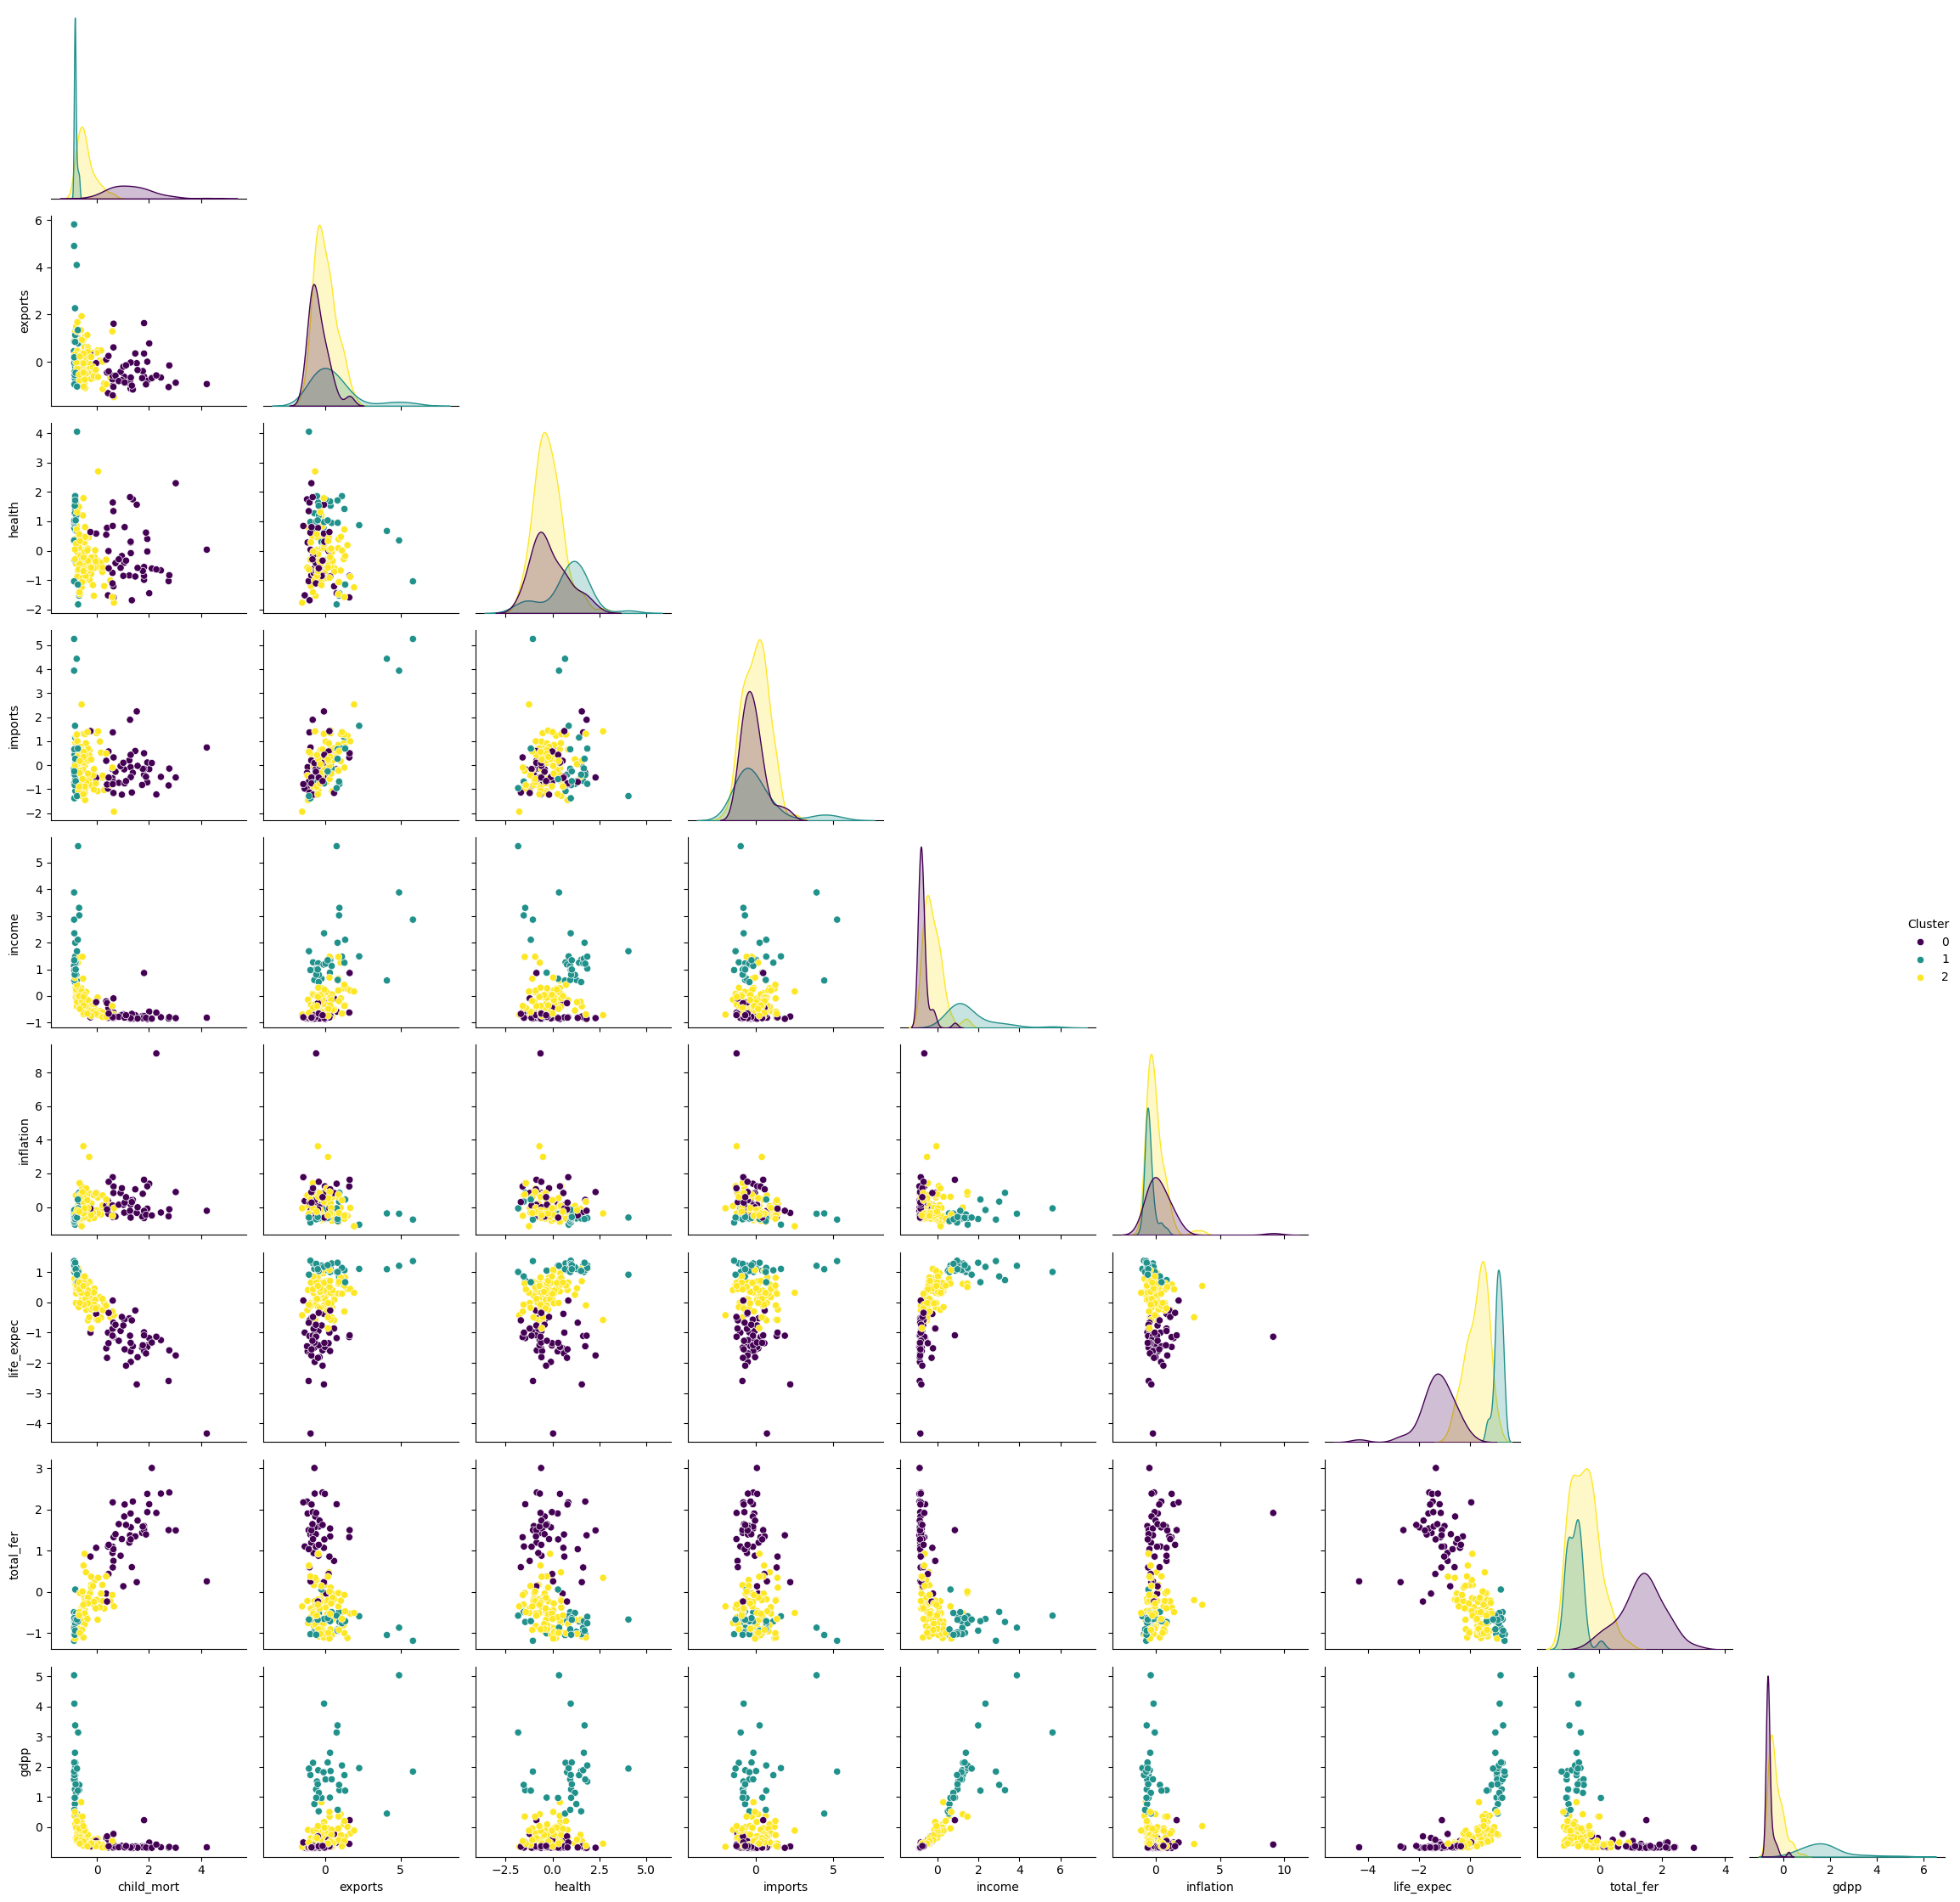

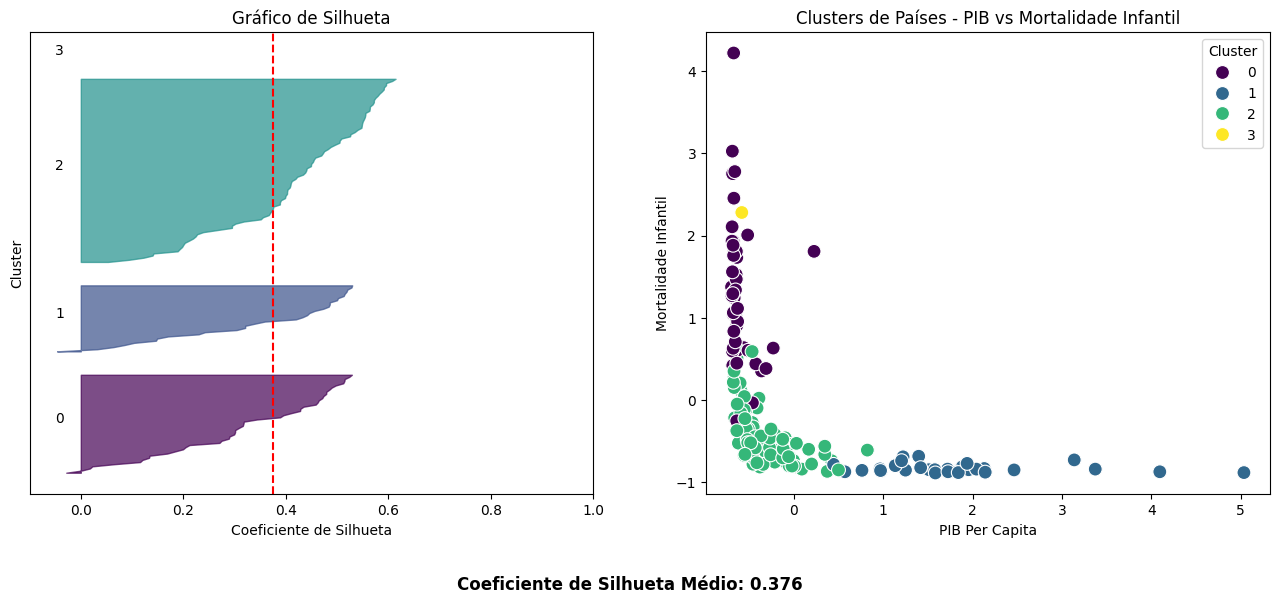

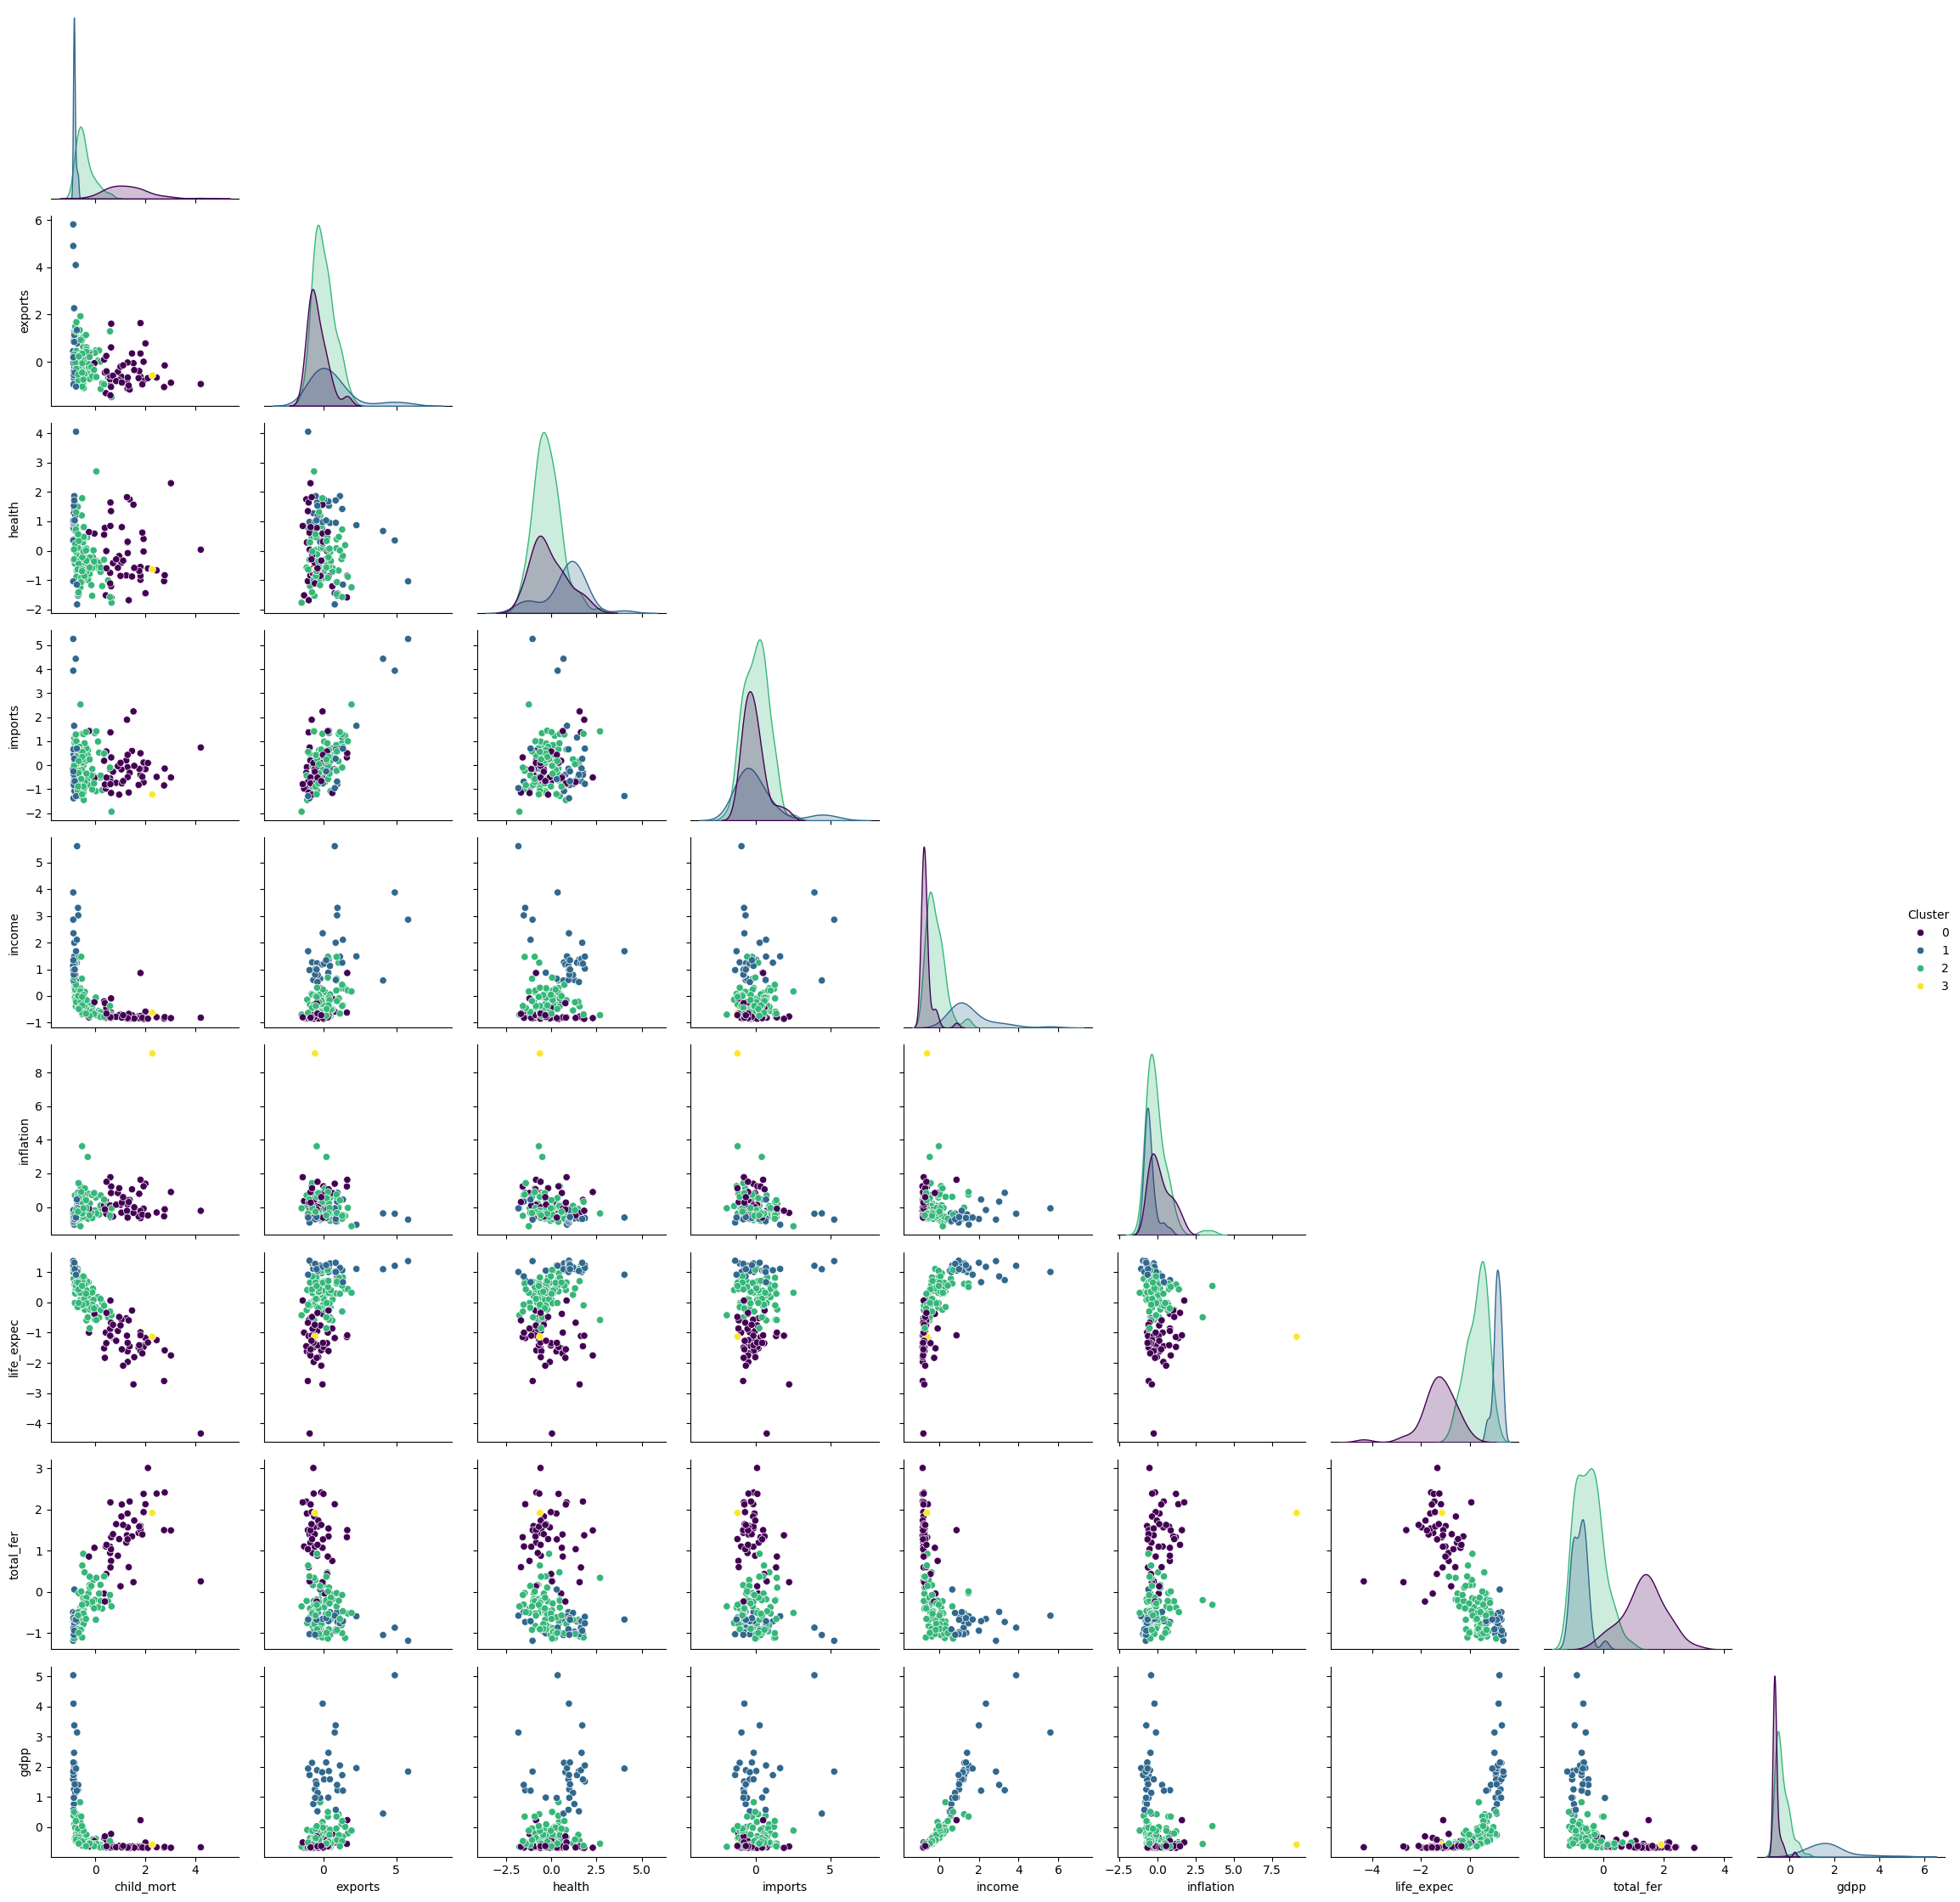

In [ ]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples


# Definir o número de clusters
cluster_range = range(2, 5)

for k in cluster_range:
  # Aplicar K-Means
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  df['Cluster'] = kmeans.fit_predict(X_scaled)

  # Calcular métricas de silhueta
  silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
  sample_silhouette_values = silhouette_samples(X_scaled, df['Cluster'])

  # Criar figura com 2 gráficos lado a lado
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

  ### 1. Gráfico de Silhueta ###
  ax1.set_xlim([-0.1, 1])
  ax1.set_ylim([0, len(X_scaled) + (k + 1) * 10])

  y_lower = 10
  for i in range(k):
      ith_cluster_silhouette_values = sample_silhouette_values[df['Cluster'] == i]
      ith_cluster_silhouette_values.sort()

      size_cluster_i = ith_cluster_silhouette_values.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cm.viridis(float(i) / k)
      ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

      ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
      y_lower = y_upper + 10  # Adiciona espaço entre os clusters

  ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
  ax1.set_title("Gráfico de Silhueta")
  ax1.set_xlabel("Coeficiente de Silhueta")
  ax1.set_ylabel("Cluster")
  ax1.set_yticks([])

  ### 2. Scatterplot dos Clusters ###
  sns.scatterplot(data=df, x='gdpp', y='child_mort', hue='Cluster', palette="viridis", s=100, ax=ax2)
  ax2.set_title('Clusters de Países - PIB vs Mortalidade Infantil')
  ax2.set_xlabel('PIB Per Capita')
  ax2.set_ylabel('Mortalidade Infantil')
  ax2.legend(title="Cluster")

  fig.text(0.5, -0.05, f"Coeficiente de Silhueta Médio: {silhouette_avg:.3f}", ha="center", fontsize=12, fontweight="bold")
  sns.pairplot(df,corner=True, hue="Cluster", palette="viridis", diag_kind="kde")
  plt.tight_layout()
  plt.show()


##**📊 Primeiro Gráfico (2 Clusters)**

 - Dois grupos bem separados, mas os coeficientes de silhueta variam bastante.

 - A maioria dos pontos tem coeficiente entre 0.2 e 0.6, o que indica uma clusterização razoável.

 - Alguns pontos próximos de 0.0, o que significa que podem estar mal agrupados.

 - A linha vermelha (~0.4) sugere uma separação moderada entre os clusters.

 - Possível problema: talvez existam subgrupos dentro desses clusters, indicando que aumentar o número de clusters pode ser útil.

##**📊 Segundo Gráfico (3 Clusters)**

 - Aqui, vemos três clusters, e a distribuição parece mais equilibrada.

 - Ainda há pontos com coeficientes próximos de zero, o que pode indicar elementos que estão na fronteira entre clusters.

 - O cluster do meio (1) parece ser o mais estreito e pode estar menos bem definido.

 - A média do coeficiente de silhueta continua próxima de 0.4, sugerindo uma separação moderada.

 Vazamento de dados (pontos com coeficiente próximo de zero ou negativo):

 - Ainda há elementos que estão na fronteira entre clusters ou no grupo errado.

 - Indica que pode haver sobreposição entre os grupos.


##**📊 Terceiro Gráfico (4 Clusters)**

✅ Ponto Positivo:

 - O coeficiente de silhueta médio aumentou, o que sugere uma melhor separação geral dos clusters.

⚠️ Problemas identificados:

1️⃣ Cluster com apenas 1 dado:

 - Isso pode significar que esse ponto é muito diferente dos outros e foi isolado.

 - Pode ser um outlier que está atrapalhando a clusterização.

 - Pode indicar que 4 clusters não é a melhor escolha.

2️⃣ Vazamento de dados (pontos com coeficiente próximo de zero ou negativo):

 - Ainda há elementos que estão na fronteira entre clusters ou no grupo errado.

 - Indica que pode haver sobreposição entre os grupos.

##**Conclusão:**
 **O segundo gráfico (3 clusters) parece levemente melhor, pois há uma separação mais clara entre os grupos.**

In [ ]:
# Selecionando k = 3:
kmeans = KMeans(3, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
# Estatísticas descritivas por cluster
numeric_columns = df.select_dtypes(include='number')
numeric_columns.groupby('Cluster').mean()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,1.326610,-0.422174,-0.139541,-0.155648,-0.689238,0.391812,-1.276276,1.354342,-0.604963
1,-0.829858,0.615071,0.803421,0.149425,1.578038,-0.481867,1.119797,-0.777775,1.771235
2,-0.426688,0.006691,-0.218523,0.030914,-0.200159,-0.038934,0.292273,-0.461145,-0.317716


##**Analise dos Clusters**

**Cluster 0 (🟣 Roxo) - Países de Baixa Renda com Altos Índices Sociais Negativos**

📉 Alta Mortalidade Infantil | Baixa Renda | Saúde Deficiente | Expectativa de Vida Baixa

🔹 Mortalidade infantil: Muito alta (+)

🔹 Exportações e importações: Abaixo da média (-)

🔹 Saúde: Ligeiramente abaixo da média (-)

🔹 Renda (PIB per capita): Baixa (-)

🔹 Inflação: Elevada (+)

🔹 Expectativa de vida: Baixa (-)

🔹 Taxa de fertilidade: Alta (+)

**💡 Interpretação:**

🔸 Representa países de economia frágil e baixos índices de desenvolvimento humano (IDH).

🔸 Alta mortalidade infantil e baixa expectativa de vida indicam problemas estruturais na saúde.

🔸 A economia é dependente do mercado interno, com exportações e importações limitadas.

🔸 Inflação elevada pode indicar instabilidade econômica.

**📌 Sugestões de Política Pública:**

✅ Investimento em infraestrutura de saúde para reduzir mortalidade infantil.

✅ Programas de incentivo à economia para aumentar exportações e melhorar o comércio internacional.

✅ Controle da inflação por meio de políticas monetárias.

**Cluster 1 (🟢 Verde) - Países Desenvolvidos e de Alta Renda**

📈 Alta Renda | Boa Saúde | Baixa Mortalidade Infantil | Longa Expectativa de Vida

🔹 Mortalidade infantil: Baixa (-)

🔹 Exportações: Altas (+)

🔹 Saúde: Acima da média (+)

🔹 Importações: Ligeiramente acima da média (+)

🔹 Renda (PIB per capita): Muito alta (++)

🔹 Inflação: Controlada (-)

🔹 Expectativa de vida: Alta (+)

🔹 Taxa de fertilidade: Baixa (-)

**💡 Interpretação:**
🔸 Representa países desenvolvidos, com alta renda e bons indicadores sociais.

🔸 A economia é forte, com grande participação no comércio internacional (altas exportações e importações).

🔸 Expectativa de vida alta e mortalidade infantil baixa sugerem sistemas de saúde eficientes.

🔸 Inflação sob controle, garantindo estabilidade econômica.

**📌 Sugestões para Manutenção do Crescimento:**

✅ Políticas de inovação para manter competitividade global.

✅ Sustentabilidade econômica para evitar crises inflacionárias.

✅ Reformas para equilibrar a taxa de fertilidade e evitar problemas populacionais futuros.

**Cluster 2 (🟡 Amarelo) - Países em Desenvolvimento com Economia Mediana**

⚖️ Renda Média | Saúde Mediana | Expectativa de Vida Moderada

🔹 Mortalidade infantil: Moderada (-)

🔹 Exportações: Próximas à média (≈)

🔹 Saúde: Ligeiramente abaixo da média (-)

🔹 Importações: Próximas à média (≈)

🔹 Renda (PIB per capita): Média (≈)

🔹 Inflação: Moderada (≈)

🔹 Expectativa de vida: Mediana (≈)

🔹 Taxa de fertilidade: Moderada (-)

**💡 Interpretação:**

🔸 Países em desenvolvimento, com crescimento econômico, mas desafios estruturais.

🔸 Mortalidade infantil e expectativa de vida indicam que a saúde está em transição.

🔸 Exportações e importações equilibradas, mas sem grande impacto na economia global.

🔸 Renda moderada e inflação relativamente estável.

**📌 Sugestões para Avanço Econômico:**

✅ Investir em tecnologia e inovação para impulsionar exportações.

✅ Reformas no setor de saúde para aumentar a qualidade de vida.

✅ Implementação de políticas fiscais para garantir estabilidade e crescimento sustentável.

